In [1]:
import pandas as pd

In [9]:
# Die angegebenen Werte sind Unterdrücke (Betrag)
# Start: -0.6 bar (höchster Unterdruck), Ende: 0 bar (Normaldruck)
df = pd.DataFrame({
    "p_video1": [0.60,0.58,0.50,0.44,0.39,0.30,0.28,0.22,0.16,0.10,0.02,0.00],  # Unterdruck (Betrag) in bar
    "N_video1": [0,3,6,9,12,15,18,21,24,27,30,33],                              # Anzahl Interferenzstreifen
    "p_video2": [0.60,0.56,0.50,0.44,0.38,0.29,0.26,0.20,0.16,0.08,0.01,0.00],  # Unterdruck (Betrag) in bar
    "N_video2": [0,3,6,9,12,15,18,21,24,27,30,33]                               # Anzahl Interferenzstreifen
})

# Δp = Druckzunahme vom Startzustand (= Betrag des Unterdrucks)
df["delta_p_video1"] = df["p_video1"]
df["delta_p_video2"] = df["p_video2"]

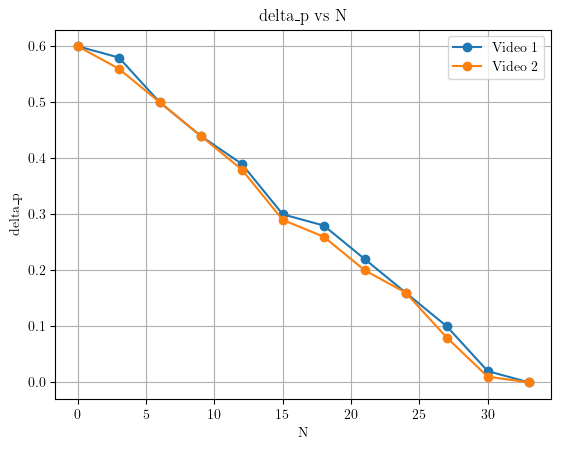

In [10]:
# plot N_video1 on x-axis and delta_p_video1 on y-axis
import matplotlib.pyplot as plt
plt.plot(df["N_video1"], df["delta_p_video1"], marker='o', label='Video 1')
plt.plot(df["N_video2"], df["delta_p_video2"], marker='o', label='Video 2')
plt.xlabel('N')
plt.ylabel('delta_p')
plt.title('delta_p vs N')
plt.legend()
plt.grid()
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from uncertainties import ufloat
from uncertainties import unumpy as unp

# Daten (siehe erste Zelle für Details)
df = pd.DataFrame({
    "p_video1": [0.60,0.58,0.50,0.44,0.39,0.30,0.28,0.22,0.16,0.10,0.02,0.00],
    "N_video1": [0,3,6,9,12,15,18,21,24,27,30,33],
    "p_video2": [0.60,0.56,0.50,0.44,0.38,0.29,0.26,0.20,0.16,0.08,0.01,0.00],
    "N_video2": [0,3,6,9,12,15,18,21,24,27,30,33]
})

df["delta_p_video1"] = df["p_video1"]
df["delta_p_video2"] = df["p_video2"]

# Konstanten
lam = 523e-9
l = ufloat(0.05, 0.5e-3)   # Länge der Gaszelle: 5 cm

# Unsicherheiten für Druck
p1 = unp.uarray(df["delta_p_video1"], 0.02)
p2 = unp.uarray(df["delta_p_video2"], 0.02)

# Δn berechnen
dn1 = df["N_video1"] * lam / (2*l)
dn2 = df["N_video2"] * lam / (2*l)

# nominalwerte für Fit
p = np.concatenate([unp.nominal_values(p1), unp.nominal_values(p2)])
dn = np.concatenate([unp.nominal_values(dn1), unp.nominal_values(dn2)])

# linearer Fit
a, b = np.polyfit(p, dn, 1)

print("Steigung dn/dp =", a)

# Plot
plt.scatter(p, dn)
plt.plot(p, a*p + b)
plt.xlabel("Δp")
plt.ylabel("Δn")
plt.show()

Steigung dn/dp = -0.00027179451506663816


RuntimeError: latex was not able to process the following string:
b'\\u0394p'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpm_r3pdzq e8dffccfcfe4e7e09c98b9404118a3b3.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./e8dffccfcfe4e7e09c98b9404118a3b3.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/la

<Figure size 640x480 with 1 Axes>

ODR Fit - chi (Steigung): -2.739216e-04 ± 6.234604e-06
         - Achsenabschnitt: 1.682509e-04 ± 2.257612e-06
ODR Fit - chi (Steigung): -2.723087e-04 ± 6.291118e-06
         - Achsenabschnitt: 1.652600e-04 ± 2.234095e-06

 AUSWERTUNG: BRECHUNGSINDEX VON LUFT IN ABHÄNGIGKEIT VOM DRUCK

                       EXPERIMENTELLE PARAMETER                       
----------------------------------------------------------------------
  Wellenlänge λ:            523.0 nm
  Länge der Gaszelle l:     5.0 ± 0.1 cm
  Temperatur:               20 ± 1 °C (293.1 ± 1.0 K)
  Druckunsicherheit σ_p:    0.02 bar
  Anzahl Messpunkte:        12 (je Messung)

                            MESSERGEBNISSE                            
----------------------------------------------------------------------

  Messung 1:
    χ₁ = (-2.739216e-04 ± 6.234604e-06) bar⁻¹
    χ₁ = (-2.7392 ± 0.0623) × 10⁻⁴ bar⁻¹
    Achsenabschnitt b₁ = (1.682509e-04 ± 2.257612e-06) (dimensionslos)

  Messung 2:
    χ₂ = (-2.723087e-04 ± 6.2

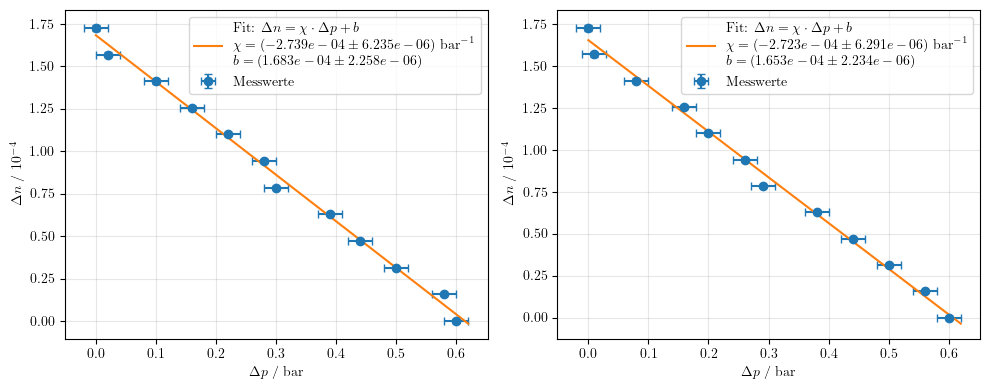

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy import odr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

# Daten - die angegebenen Werte sind Unterdrücke (negativ)
# Der maximale Unterdruck war -0.6 bar, dann wurde Luft eingelassen bis 0 bar
df = pd.DataFrame({
    "p_video1": [0.60,0.58,0.50,0.44,0.39,0.30,0.28,0.22,0.16,0.10,0.02,0.00],  # Unterdruck (Betrag)
    "N_video1": [0,3,6,9,12,15,18,21,24,27,30,33],
    "p_video2": [0.60,0.56,0.50,0.44,0.38,0.29,0.26,0.20,0.16,0.08,0.01,0.00],  # Unterdruck (Betrag)
    "N_video2": [0,3,6,9,12,15,18,21,24,27,30,33]
})

# Berechne Δp: Druckdifferenz zum Endzustand (0 bar)
# Δp ist positiv, wenn Druck zunimmt
df["delta_p_video1"] = df["p_video1"]  # Δp = 0 - (-p) = p (Betrag des Unterdrucks)
df["delta_p_video2"] = df["p_video2"]

# Konstanten
lam = 523e-9  # Wellenlänge in m
l = ufloat(0.05, 0.5e-3)  # Länge der Gaszelle in m (5 cm)
T = ufloat(20, 1)  # Temperatur in °C
T_K = T + 273.15  # Temperatur in Kelvin

sigma_p = 0.02  # Unsicherheit des Drucks in bar

def compute_dataset(delta_p, N):
    """
    Berechnet χ (chi) aus der Beziehung: Δn/Δp = χ
    wobei Δn = N·λ/(2·l)

    Parameters:
    -----------
    delta_p : array-like
        Druckänderung in bar
    N : array-like
        Anzahl der Interferenzstreifen

    Returns:
    --------
    delta_p, dn_nom, dn_err, chi, b
    """

    delta_p = np.array(delta_p)
    N = np.array(N)

    # Δn berechnen mit Unsicherheiten
    dn = N * lam / (2*l)

    dn_nom = unp.nominal_values(dn)
    dn_err = unp.std_devs(dn)

    # Setze minimale Unsicherheit für y-Werte, falls zu klein
    dn_err = np.where(dn_err > 1e-10, dn_err, 1e-6)

    def lin(B, x):
        return B[0]*x + B[1]

    model = odr.Model(lin)

    data = odr.RealData(
        delta_p,
        dn_nom,
        sx=np.full_like(delta_p, sigma_p),
        sy=dn_err
    )

    # Fit: Δn = χ·Δp + b
    # Die Steigung ist χ (chi), die elektrische Suszeptibilität
    odr_obj = odr.ODR(data, model, beta0=[3e-4, 0])
    out = odr_obj.run()

    # Debug-Ausgabe
    print(f"ODR Fit - chi (Steigung): {out.beta[0]:.6e} ± {out.sd_beta[0]:.6e}")
    print(f"         - Achsenabschnitt: {out.beta[1]:.6e} ± {out.sd_beta[1]:.6e}")

    chi = ufloat(out.beta[0], out.sd_beta[0])
    b = ufloat(out.beta[1], out.sd_beta[1])

    return delta_p, dn_nom, dn_err, chi, b


dp1, dn1, dn1_err, chi1, b1 = compute_dataset(df["delta_p_video1"], df["N_video1"])
dp2, dn2, dn2_err, chi2, b2 = compute_dataset(df["delta_p_video2"], df["N_video2"])

print("\n" + "="*70)
print(" AUSWERTUNG: BRECHUNGSINDEX VON LUFT IN ABHÄNGIGKEIT VOM DRUCK")
print("="*70)

print(f"\n{'EXPERIMENTELLE PARAMETER':^70}")
print("-"*70)
print(f"  Wellenlänge λ:            {lam*1e9:.1f} nm")
print(f"  Länge der Gaszelle l:     {l.n*100:.1f} ± {l.s*100:.1f} cm")
print(f"  Temperatur:               {T.n:.0f} ± {T.s:.0f} °C ({T_K.n:.1f} ± {T_K.s:.1f} K)")
print(f"  Druckunsicherheit σ_p:    {sigma_p} bar")
print(f"  Anzahl Messpunkte:        {len(df['N_video1'])} (je Messung)")

print(f"\n{'MESSERGEBNISSE':^70}")
print("-"*70)
print(f"\n  Messung 1:")
print(f"    χ₁ = ({chi1.n:.6e} ± {chi1.s:.6e}) bar⁻¹")
print(f"    χ₁ = ({chi1.n*1e4:.4f} ± {chi1.s*1e4:.4f}) × 10⁻⁴ bar⁻¹")
print(f"    Achsenabschnitt b₁ = ({b1.n:.6e} ± {b1.s:.6e}) (dimensionslos)")
print(f"\n  Messung 2:")
print(f"    χ₂ = ({chi2.n:.6e} ± {chi2.s:.6e}) bar⁻¹")
print(f"    χ₂ = ({chi2.n*1e4:.4f} ± {chi2.s*1e4:.4f}) × 10⁻⁴ bar⁻¹")
print(f"    Achsenabschnitt b₂ = ({b2.n:.6e} ± {b2.s:.6e}) (dimensionslos)")

# gewichteter Mittelwert von χ
# Check if uncertainties are non-zero to avoid division by zero
if chi1.s > 1e-12 and chi2.s > 1e-12:
    weights = np.array([1/chi1.s**2, 1/chi2.s**2])
    mean = (chi1.n*weights[0] + chi2.n*weights[1]) / weights.sum()
    sigma = np.sqrt(1/weights.sum())
    chi_mittel = ufloat(mean, sigma)
    mittelwert_methode = "Gewichteter Mittelwert"
    print(f"\n  Gewichte: w₁ = {weights[0]:.2e}, w₂ = {weights[1]:.2e}")
else:
    # If uncertainties are zero, use simple arithmetic mean
    chi_mittel = (chi1 + chi2) / 2
    mittelwert_methode = "Arithmetischer Mittelwert"

print(f"\n  {'GEMITTELTES χ':^68}")
print(f"  {'-'*68}")
print(f"    Methode: {mittelwert_methode}")
print(f"    χ_mittel = ({chi_mittel.n:.6e} ± {chi_mittel.s:.6e}) bar⁻¹")
print(f"    χ_mittel = ({chi_mittel.n*1e4:.4f} ± {chi_mittel.s*1e4:.4f}) × 10⁻⁴ bar⁻¹")

# Berechne Brechungsindex bei Normalbedingungen (1 bar, 20°C)
# Verwende Gladstone-Dale: n - 1 = χ · p
# Bei p = 1 bar:
p_norm = 1.0  # bar
n_minus_1 = chi_mittel * p_norm
n_luft = 1 + n_minus_1

print(f"\n{'BRECHUNGSINDEX BEI NORMALBEDINGUNGEN':^70}")
print("-"*70)
print(f"  Druck p₀:                 {p_norm} bar")
print(f"  Temperatur:               {T.n:.0f}°C")
print(f"\n  Verwendete Formel: n - 1 = χ · p  (Gladstone-Dale)")
print(f"\n  n - 1 = ({n_minus_1.n:.6e} ± {n_minus_1.s:.6e})")
print(f"  n - 1 = ({(n_minus_1.n)*1e6:.1f} ± {(n_minus_1.s)*1e6:.1f}) × 10⁻⁶")
print(f"\n  n_Luft = {n_luft.n:.8f} ± {n_luft.s:.8f}")
print(f"  n_Luft = 1 + ({(n_luft.n - 1)*1e6:.1f} ± {(n_luft.s)*1e6:.1f}) × 10⁻⁶")

# Vergleich mit Literaturwert
n_lit = 1.000293  # Literaturwert für Luft bei 15°C, 1 bar, 589 nm (gelb)
abweichung = abs(n_luft.n - n_lit)
abw_prozent = (abweichung / (n_lit - 1)) * 100

print(f"\n{'VERGLEICH MIT LITERATUR':^70}")
print("-"*70)
print(f"  Literaturwert (15°C, 1 bar, 589 nm):")
print(f"    n_Luft(Lit) = {n_lit}")
print(f"    n_Luft(Lit) - 1 = {(n_lit-1)*1e6:.1f} × 10⁻⁶")
print(f"\n  Abweichung:")
print(f"    Δn = {abweichung:.6e}")
print(f"    Relative Abweichung: {abw_prozent:.1f}%")
print(f"    Anzahl Standardabweichungen: {abs(n_luft.n - n_lit)/n_luft.s:.1f}σ")

print("\n" + "="*70)
print(" ZUSAMMENFASSUNG FÜR DIE AUSARBEITUNG")
print("="*70)
print(f"""
METHODE:
  - Michelson-Interferometer mit Gaszelle (l = {l.n*100:.0f} cm)
  - Druckvariation von 0 bis 0.6 bar Unterdruck
  - Wellenlänge λ = {lam*1e9:.0f} nm (grün)
  - Temperatur T = {T.n:.0f} ± {T.s:.0f} °C (konstant während der Messung)

MESSWERTE:
  - Anzahl der Messungen: 2
  - Je {len(df['N_video1'])} Messpunkte
  - Zählung der Interferenzstreifen N bei verschiedenen Drücken

AUSWERTUNG:
  - Berechnung von Δn = N·λ/(2·l)  [Δn dimensionslos]
  - Linearer Fit: Δn = χ·Δp + b
  - χ ist die dielektrische Suszeptibilität mit Einheit [bar⁻¹]
  - X-Achse: Δp in [bar] (Druckänderung)
  - Y-Achse: Δn [dimensionslos] (Brechungsindexänderung)

ERGEBNISSE:
  χ = ({chi_mittel.n:.3e} ± {chi_mittel.s:.3e}) bar⁻¹
  χ = ({chi_mittel.n*1e4:.4f} ± {chi_mittel.s*1e4:.4f}) × 10⁻⁴ bar⁻¹

  Brechungsindex bei Normalbedingungen (1 bar, {T.n:.0f}°C):
  n_Luft = {n_luft.n:.6f} ± {n_luft.s:.6f}  [dimensionslos]

  Literaturvergleich:
  - Gemessen: n - 1 = {(n_luft.n - 1)*1e6:.1f} × 10⁻⁶
  - Literatur: n - 1 = {(n_lit - 1)*1e6:.1f} × 10⁻⁶
  - Abweichung: {abw_prozent:.1f}%

EINHEITEN-ÜBERSICHT:
  - Δp: bar (Druckänderung)
  - Δn: dimensionslos (Brechungsindexänderung)
  - χ: bar⁻¹ (Suszeptibilität, zeigt Δn pro bar Druckänderung)
  - n: dimensionslos (Brechungsindex)
  - T: °C oder K (Temperatur, hier konstant bei {T.n:.0f}°C)

FEHLERQUELLEN:
  - Temperaturunsicherheit (±{T.s:.0f}°C)
  - Druckmessung (±{sigma_p} bar)
  - Längenbestimmung der Gaszelle (±{l.s*100:.1f} cm)
  - Zählung der Interferenzstreifen
  - Luftfeuchtigkeit nicht berücksichtigt
""")
print("="*70 + "\n")


# Plot
fig, axes = plt.subplots(1,2,figsize=(10,4))

xfit = np.linspace(0,0.62,200)

# Skalierungsfaktor für y-Achse (10^-4)
scale = 1e4

axes[0].errorbar(
    dp1,
    dn1 * scale,
    xerr=sigma_p,
    yerr=dn1_err * scale,
    fmt="o",
    capsize=3,
    label="Messwerte"
)

axes[0].plot(
    xfit,
    (chi1.n*xfit + b1.n) * scale,
    label=fr"Fit: $\Delta n = \chi \cdot \Delta p + b$" + "\n" +
          fr"$\chi = ({chi1.n:.3e} \pm {chi1.s:.3e})\ \mathrm{{bar}}^{{-1}}$" + "\n" +
          fr"$b = ({b1.n:.3e} \pm {b1.s:.3e})$"
)

axes[0].set_xlabel(r"$\Delta p\ /\ \mathrm{bar}$")
axes[0].set_ylabel(r"$\Delta n\ /\ 10^{-4}$")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].errorbar(
    dp2,
    dn2 * scale,
    xerr=sigma_p,
    yerr=dn2_err * scale,
    fmt='o',
    capsize=3,
    label="Messwerte"
)

axes[1].plot(
    xfit,
    (chi2.n*xfit + b2.n) * scale,
    label=fr"Fit: $\Delta n = \chi \cdot \Delta p + b$" + "\n" +
          fr"$\chi = ({chi2.n:.3e} \pm {chi2.s:.3e})\ \mathrm{{bar}}^{{-1}}$" + "\n" +
          fr"$b = ({b2.n:.3e} \pm {b2.s:.3e})$"
)

axes[1].set_xlabel(r"$\Delta p\ /\ \mathrm{bar}$")
axes[1].set_ylabel(r"$\Delta n\ /\ 10^{-4}$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
# save as svg
plt.savefig("brechungsindex_luft.svg", format="svg", bbox_inches="tight", dpi=150)

In [18]:
# Detaillierte Tabelle für die Ausarbeitung
print("\n" + "="*90)
print(" MESSWERTE-TABELLE FÜR DIE AUSARBEITUNG")
print("="*90)

print("\nMessung 1:")
print("-"*90)
print(f"{'N':<8} {'Δp / bar':<12} {'Δn':<18} {'Δn / 10⁻⁴':<15}")
print("-"*90)
for i in range(len(df["N_video1"])):
    N = df["N_video1"][i]
    p = df["delta_p_video1"][i]
    dn = dn1[i]
    dn_e = dn1_err[i]
    print(f"{N:<8} {p:<12.2f} {dn:.6e} ± {dn_e:.2e}   {dn*1e4:<15.4f} ± {dn_e*1e4:.4f}")

print("\n\nMessung 2:")
print("-"*90)
print(f"{'N':<8} {'Δp / bar':<12} {'Δn':<18} {'Δn / 10⁻⁴':<15}")
print("-"*90)
for i in range(len(df["N_video2"])):
    N = df["N_video2"][i]
    p = df["delta_p_video2"][i]
    dn = dn2[i]
    dn_e = dn2_err[i]
    print(f"{N:<8} {p:<12.2f} {dn:.6e} ± {dn_e:.2e}   {dn*1e4:<15.4f} ± {dn_e*1e4:.4f}")

print("\n" + "="*90)
print(" LATEX-TABELLE FÜR DIE AUSARBEITUNG")
print("="*90)

print("""
\\begin{table}[h]
\\centering
\\caption{Messwerte der Interferenzstreifenzählung in Abhängigkeit vom Druck}
\\begin{tabular}{c|c|c||c|c|c}
\\hline
\\multicolumn{3}{c||}{Messung 1} & \\multicolumn{3}{c}{Messung 2} \\\\
\\hline
$N$ & $\\Delta p$ / bar & $\\Delta n / 10^{-4}$ & $N$ & $\\Delta p$ / bar & $\\Delta n / 10^{-4}$ \\\\
\\hline""")

for i in range(len(df["N_video1"])):
    N1 = df["N_video1"][i]
    p1 = df["delta_p_video1"][i]
    dn1_val = dn1[i]*1e4

    N2 = df["N_video2"][i]
    p2 = df["delta_p_video2"][i]
    dn2_val = dn2[i]*1e4

    print(f"{N1} & {p1:.2f} & {dn1_val:.3f} & {N2} & {p2:.2f} & {dn2_val:.3f} \\\\")

print("""\\hline
\\end{tabular}
\\label{tab:messwerte}
\\end{table}
""")

print("\n" + "="*90)
print(" FORMELN FÜR DIE AUSARBEITUNG")
print("="*90)

print("""
VERWENDETE FORMELN:

1. Brechungsindexänderung aus Interferenzen:
   Δn = N·λ/(2·l)

   wobei:
   - N: Anzahl der gezählten Interferenzstreifen [dimensionslos]
   - λ: Wellenlänge des Lasers [m]
   - l: Länge der Gaszelle [m]
   - Δn: Brechungsindexänderung [dimensionslos]

2. Gladstone-Dale-Beziehung (bei konstanter Temperatur):
   Δn/Δp = χ

   oder für Normalbedingungen:
   n - 1 = χ·p

   wobei:
   - χ: dielektrische Suszeptibilität [bar⁻¹]
   - p: Druck [bar]
   - Δp: Druckänderung [bar]
   - n: Brechungsindex [dimensionslos]

3. Linearer Fit:
   Δn = χ·Δp + b

   Die Steigung χ [bar⁻¹] wird durch orthogonale Distanz-Regression (ODR)
   bestimmt, wobei sowohl x- als auch y-Unsicherheiten berücksichtigt werden.

4. Gewichteter Mittelwert:
   χ_mittel = (w₁·χ₁ + w₂·χ₂) / (w₁ + w₂)

   mit Gewichten: w_i = 1/σ_i²

   Unsicherheit: σ_mittel = √(1/(w₁ + w₂))

EINHEITEN-ANALYSE:
   - X-Achse im Plot: Δp [bar] - Druckänderung
   - Y-Achse im Plot: Δn [dimensionslos] - Brechungsindexänderung
   - Steigung χ: [Δn]/[Δp] = [dimensionslos]/[bar] = [bar⁻¹]
   - Bei T = const: χ beschreibt, um wieviel sich n pro bar Druckänderung ändert
""")

print("="*90)


 MESSWERTE-TABELLE FÜR DIE AUSARBEITUNG

Messung 1:
------------------------------------------------------------------------------------------
N        Δp / bar     Δn                 Δn / 10⁻⁴      
------------------------------------------------------------------------------------------
0        0.60         0.000000e+00 ± 1.00e-06   0.0000          ± 0.0100
3        0.58         1.569000e-05 ± 1.57e-07   0.1569          ± 0.0016
6        0.50         3.138000e-05 ± 3.14e-07   0.3138          ± 0.0031
9        0.44         4.707000e-05 ± 4.71e-07   0.4707          ± 0.0047
12       0.39         6.276000e-05 ± 6.28e-07   0.6276          ± 0.0063
15       0.30         7.845000e-05 ± 7.84e-07   0.7845          ± 0.0078
18       0.28         9.414000e-05 ± 9.41e-07   0.9414          ± 0.0094
21       0.22         1.098300e-04 ± 1.10e-06   1.0983          ± 0.0110
24       0.16         1.255200e-04 ± 1.26e-06   1.2552          ± 0.0126
27       0.10         1.412100e-04 ± 1.41e-06   1.4